In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


from kineticanalysis.generator.generator_track import (generate_tracks, generate_one_track)
from kineticanalysis.analysis.analysis_track import single_track_analysis, check_track_validity

In [2]:
path_save = "/home/u2175049/Documents/Code/KineticAnalysis/notebook/figures/"
path = "/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/10_MNratio_Equation/"

In [29]:
prot_aa_size = {
    "32xsuntag": 796,  #768/32=24 , left 28
    "linker": 4,
    "twist": 490,
    "ilp4": 134,
    "snail": 390,
    "very_long_prot":1200,
    "same_prot":750,
}

In [30]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["same_prot"]
elongation_rate = 5

In [31]:
for i in range(200):
    x_global, y_global, y_start_prot = generate_one_track(prot_length = prot_aa_size["same_prot"], 
                                                      suntag_length = prot_aa_size["32xsuntag"], 
                                                      nb_suntag=32, 
                                                      fluo_one_suntag=4, 
                                                      translation_rate=elongation_rate, 
                                                      binding_rate=0.05,
                                                      step = 0.1,
                                                      length=85000, 
                                                       remove_point_beginning=10000)
    if i == 0:
        datas = pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })
    else:
        datas = pd.concat([datas, 
                           pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })], ignore_index=True)

datas.to_csv(os.path.join(path, "datas_track_length_translation_rate_5_equal_prot_750.csv"))

In [32]:
datas

,FRAME,MEAN_INTENSITY_CH1,TRACK_ID
0,0.0,1981.748744,0
1,0.1,1982.874372,0
2,0.2,1984.000000,0
3,0.3,1985.125628,0
4,0.4,1986.251256,0
...,...,...,...
167999995,83999.5,1925.788945,199
167999996,83999.6,1926.190955,199
167999997,83999.7,1926.592965,199
167999998,83999.8,1926.994975,199


In [ ]:
datas_track_length_translation_rate_5_short_prot_134
ilp4

datas_track_length_translation_rate_5_long_prot_1200
very_long_prot

datas_track_length_translation_rate_5_equal_prot_750
same_prot

In [69]:
datas = pd.read_csv(os.path.join(path, "datas_track_length_translation_rate_5_short_prot_134.csv"), index_col="Unnamed: 0")
# Utiliser t comme base de la boucle
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["ilp4"]
first = True


for t in [50]:
    dt = t*0.1
    for length_track in [1800]:       
        nb_point = int(length_track/dt)
        
        for i in range(200):
            datas2 = datas[datas["TRACK_ID"]==i][::t][:nb_point]
            datas2["FRAME"] = np.arange(nb_point)
            if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 1) & (len(datas2) in [30,60,300,600,1200,1800,2700,3600]):
                
                (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                       i,
                                                       normalise_intensity=1,
                                                       delta_t=dt,
                                                       rtol=1e-1,
                                                       nb_missing_point=0,
                                                       )
    
                for method in ["exact", "epitope", "approx"]:
                    (x_auto, 
                     y_auto, 
                     k, c,
                     elongation_r, 
                     translation_init_r,
                     perr) = single_track_analysis(x, 
                                                 y, 
                                                 delta_t = dt,
                                                 protein_size=prot_aa_size["same_prot"],
                                                 suntag_size =prot_aa_size["ilp4"], 
                                                 repetition_suntag = 32,
                                                 mm=None,
                                                 method=method,
                                                 simulation=True)
                    if first:
                        results = pd.DataFrame({"elongation_r":elongation_r, 
                                                "init_translation_r":translation_init_r, 
                                                "dt":dt,
                                                "long_track":datas2.shape[0],
                                                "k":k,
                                                "c":c,
                                               "id":i,
                                               "method":method,
                                               "M/N": prot_aa_size["ilp4"]/prot_aa_size["32xsuntag"]},
                                              index=[0])
                        first = False
                    
                    else:
                        results = pd.concat([results, 
                                        pd.DataFrame({"elongation_r":elongation_r, 
                                                      "init_translation_r":translation_init_r, 
                                                      "dt":dt, 
                                                      "long_track":datas2.shape[0],
                                                      "k":k,
                                                        "c":c,
                                                      "id":i,
                                                      "method":method,
                                                     "M/N": prot_aa_size["ilp4"]/prot_aa_size["32xsuntag"]}, index=[0])
                                        ], ignore_index=True)
                        
results.to_csv(os.path.join(path, "results_track_length_translation_rate_5_short_prot_134.csv"))

In [70]:
results_short = pd.read_csv(os.path.join(path, "results_track_length_translation_rate_5_short_prot_134.csv"), index_col="Unnamed: 0")
results_equal = pd.read_csv(os.path.join(path, "results_track_length_translation_rate_5_equal_prot_750.csv"), index_col="Unnamed: 0")
results_long = pd.read_csv(os.path.join(path, "results_track_length_translation_rate_5_long_prot_1200.csv"), index_col="Unnamed: 0")

results = pd.concat([results_short, results_equal, results_long])

In [71]:
results["M/N"] = results["M/N"].round(2)
results.groupby(by=['method', 'M/N'])[['elongation_r','init_translation_r', 'k', 'c', "long_track",]].mean()

elongation_r  init_translation_r           k         c  \
method  M/N                                                            
approx  0.17     28.427874            1.549479   51.385894  1.549479   
        0.94     22.708413            0.285581  208.846502  0.285581   
        1.51     15.918717            0.179073  276.207103  0.179073   
epitope 0.17      5.239471            0.077090    0.218311  0.077090   
        0.94      3.239727            0.100763    0.134989  0.100763   
        1.51      2.621278            0.116265    0.109220  0.116265   
exact   0.17     10.467467            0.239913    0.420803  0.239913   
        0.94      6.586267            0.098077    0.264775  0.098077   
        1.51      7.059580            0.112070    0.283802  0.112070   

              long_track  
method  M/N               
approx  0.17       600.0  
        0.94       600.0  
        1.51       600.0  
epitope 0.17       600.0  
        0.94       600.0  
        1.51       600.0  
exact   0.17       600.0  
        0.94       600.0  
        1.51       600.0

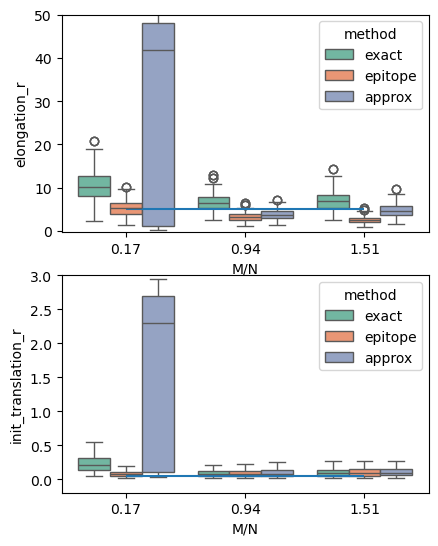

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [73]:
import seaborn as sns
# results_crop = results[results["length_track"]>60]

fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="M/N", y="elongation_r", hue="method", data=results, palette="Set2", showfliers=True, ax = axes[0])
axes[0].set_ylim(-0.2, 50)
axes[0].hlines(elongation_rate, 0.0, 2)

sns.boxplot(x="M/N", y="init_translation_r", hue="method", data=results, palette="Set2", showfliers=False, ax = axes[1])
axes[1].set_ylim(-0.2, 3)
axes[1].hlines(0.05, 0.0, 2)

fig.set_size_inches(2.37*2,6.21)
plt.show()
fig.savefig(os.path.join(path_save, "comparemethod_MN.eps"), dpi=300)

In [50]:
pd.crosstab(results["M/N"], results["method"], values=results["elongation_r"], aggfunc="mean")

method,approx,epitope,exact
M/N,,,
0.17,28.427874,5.239471,10.467467
0.94,22.708413,3.239727,6.586267
1.51,15.918717,2.621278,7.059580


In [52]:
pd.crosstab(results["M/N"], results["method"], values=results["init_translation_r"], aggfunc="mean")

method,approx,epitope,exact
M/N,,,
0.17,1.549479,0.077090,0.239913
0.94,0.285581,0.100763,0.098077
1.51,0.179073,0.116265,0.112070
